[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/OWL-ML/IBFW-PY-2026-Tutorial/blob/main/visualization_pandas.ipynb)

*(Tip: Ctrl/Cmd + click to open in a new tab)*

# Visualisierung von Pandas-DataFrames / *Visualizing pandas data frames*

In den bisherigen Visualisierungsteilen haben wir hauptsächlich simulierte Daten dargestellt, die direkt im Code definiert waren. Meistens werden wir jedoch Daten aus externen Dateien laden, unter Verwendung der Ladefunktionen und Datenformate, die wir bereits kennengelernt haben. Eine besonders häufig visualisierte Datenart sind CSV-Dateien und allgemein beliebige Pandas DataFrames.

Machen wir uns vorerst keine Sorgen über die Details der unten geladenen Datensätze. Die Idee ist, sie visuell zu erkunden und auf diese Weise ein Verständnis zu gewinnen! Falls nötig, öffne parallel unser früheres Notebook zu DataFrames.

---

*In our earlier visualization parts we mostly visualized simulated data that was defined right where we coded. Most of the time, we will naturally load data from some external file, using the loading functionality and data formats we have learned about. One kind of data that is particularly common to visuallize are csv files and arbitrary pandas DataFrames more generally.*

*Don't worry about the specifics of the datasets that are being loaded below for now. The idea is to start exploring it visually and gaining an understanding that way! If you want and if necessary, open our earlier notebook on DataFrames in parallel.*

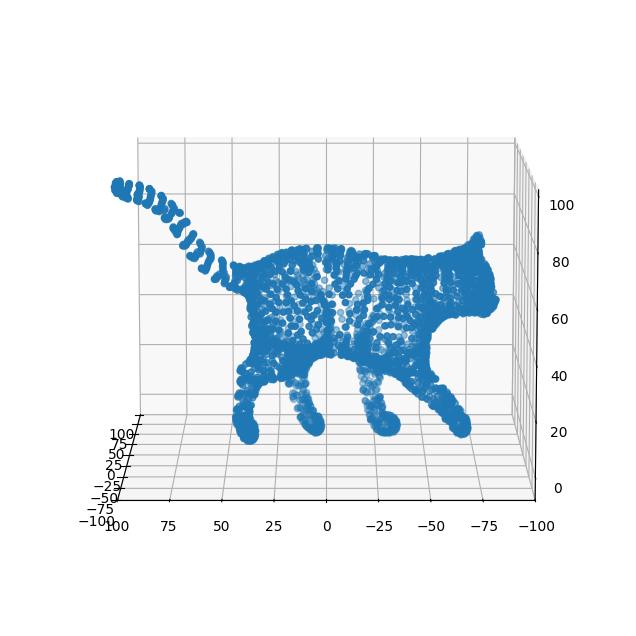

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns # extensiton von matplot für zusätzliche visualisierungsmöglichkeiten

# use pandas to read csv data from url
source = "https://raw.githubusercontent.com/PointCloudLibrary/data/master/tutorials/ism_train_cat.pcd"
cat_df = pd.read_csv(source, skiprows=11, delimiter=" ", names=["x","y","z"], encoding='latin_1')
cat_df.head()

# visualize the data in 3-d using a scatter plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d', facecolor='white')
ax.scatter(cat_df.x, cat_df.y, cat_df.z)
ax.view_init(azim=180, elev=10) # Blickwinkel
plt.ylim((-100,100))
plt.xlim((-100,100))
plt.show()

Wie wir sehen können, besteht die Datenmenge aus Punkten, die die Form einer Katze darstellen – eine sogenannte Punktwolke (Point-Cloud), die z.B. mit LiDAR-Sensoren erfasst wird.

Schauen wir uns einen sehr bekannten Datensatz an, um etwas über Visualisierung, Data Science und später maschinelles Lernen zu lernen: den Iris-Blumendatensatz. Dieses Mal laden wir ihn direkt aus einer Bibliothek, da wir davon ausgehen, dass wir inzwischen wissen, wie Daten geladen werden können.

Stattdessen konzentrieren wir uns auf eine Reihe interessanter Diagramme, die uns die Bibliothek Seaborn – eine fortgeschrittene Plotting-Bibliothek auf Basis von Matplotlib – bietet, um Pandas DataFrames direkt zu visualisieren.

---

*As we can see, the data consists of points that depict the shape of a cat, a so called point-cloud (that could be acquired e.g. with lidar sensors).*

*Let's explore a very common dataset to learn about visualization, data science, and later machine learning: the iris flower dataset. This time, we'll load it directly from a library, as we assume you are aware of how to load data by now.*

*Instead, we'll focus on a bunch of interesting plots that the seaborn library, an advanced plotting library on top of matplotlib, provides us to directly visualize pandas DataFrames.*

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 12.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


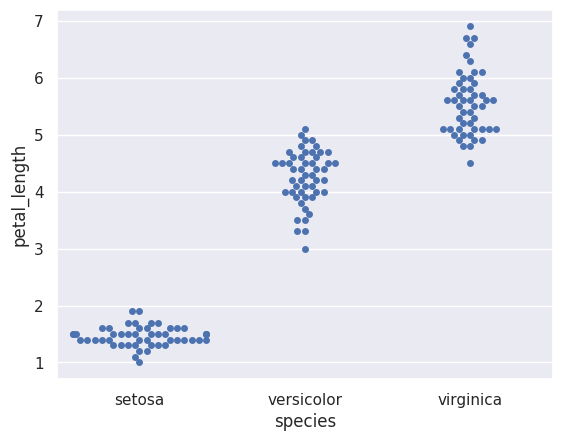

In [2]:
# Load iris data as an example of a dataset with different attributes.
fig = plt.figure()
iris = sns.load_dataset("iris")
sns.set()

# like a scatter plot, but with categories
sns.swarmplot(x="species", y="petal_length", data=iris)
plt.show()

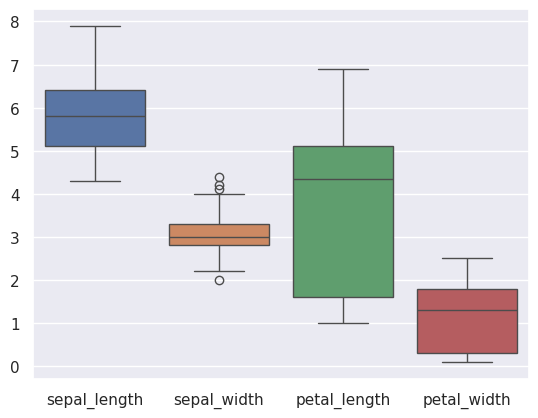

In [3]:
fig = plt.figure()
# a plot that allows us to visualize basic statistics, like mean,
# quartiles, and data outliers (the circles)
sns.boxplot(data=iris)
plt.show()

Es gibt noch viele weitere komplexe Diagramme, bei denen wir im Grunde nur eine einzige Codezeile aufrufen müssen (wobei natürlich viele, viele Zeilen im Hintergrund in den Funktionen von Seaborn und Matplotlib verborgen sind), sofern das DataFrame gut strukturiert ist. Falls wir bisher noch nicht davon überzeugt waren, gute Datenformate auszuwählen, hoffen wir, dass jetzt ein praktischeren Grund geliefert wurde, warum es wichtig ist, sorgfältig darüber nachzudenken, wie Daten gespeichert und geladen werden.

---

*There are many more complex plots that allow you to essentially call a single line of code (and obviously many many lines of code abstracted away from you in the actual function implementations of the seaborn and matplotlib libraries), if your DataFrame is well structured. If you haven't been convinced about choosing good data formats earlier throughout the course, we hope this gives you a more practical reason why thinking thoroughly of how to store and load is important.*

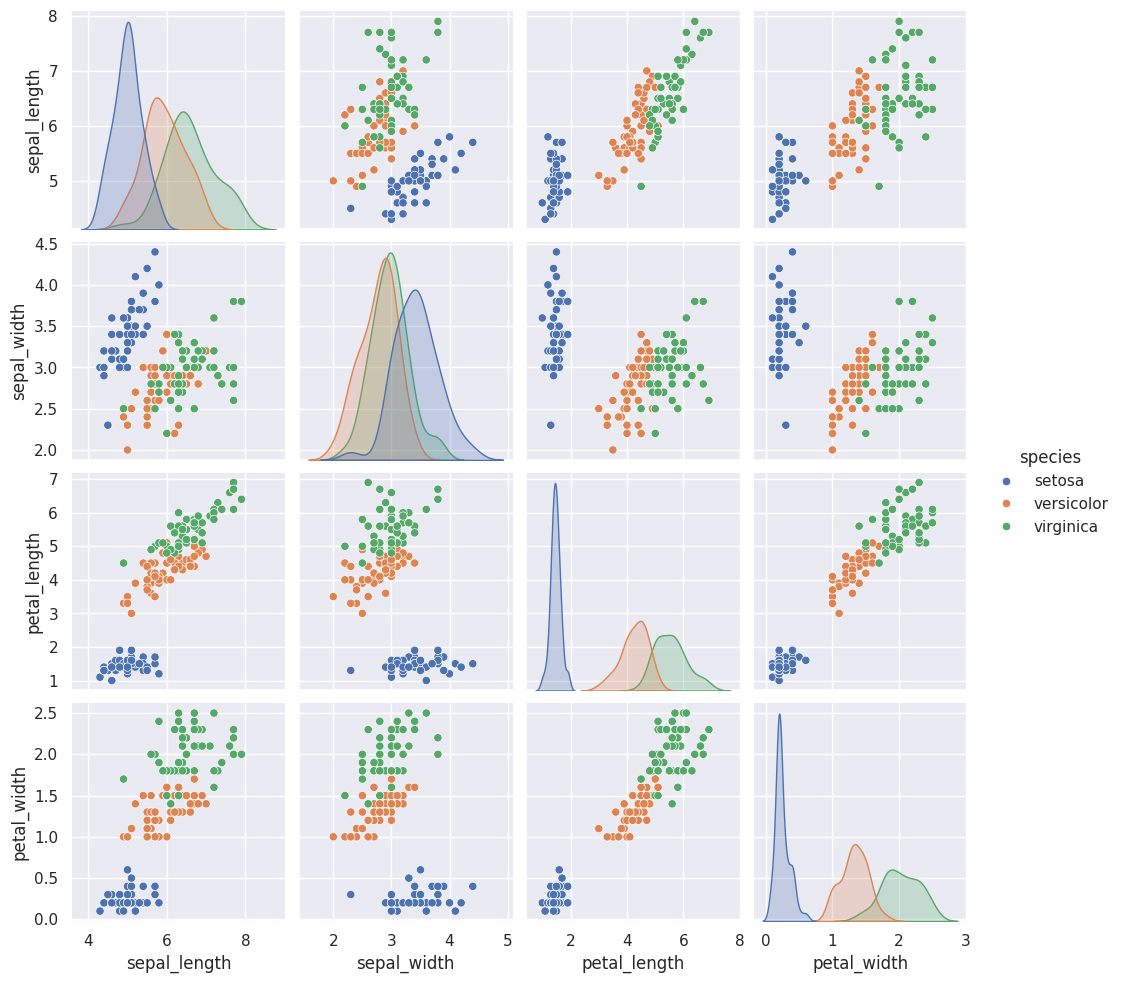

In [ ]:
sns.pairplot(data=iris, hue='species')
plt.show()

### Kurze Übungsaufgabe / *Quick exercise*

Das Anscombe-Quartett ist ein weiteres Beispiel dafür. Wenn wir uns erinnern, hatten alle Datensätze dieselben Statistiken. Mittlerweile haben Forschende viele weitere solcher Beispiele untersucht, bei denen Visualisierung entscheidend ist, um Unterschiede zwischen den Daten zu erkennen – etwas, das allein durch Array-Operationen und Statistik deutlich schwerer zu erfassen ist. Ein solches Beispiel ist der Datasaurus-Datensatz, den wir hier herunterladen können: https://www.autodesk.com/content/dam/autodesk/www/autodesk-reasearch/Publications/pdf/SameStatsCode.zip

* Lade den Datensatz herunter und importiere `DatasaurusDozen.tsv` mit der Pandas-Funktion `read_csv` – als Auffrischung zu Pandas. Um den Datensatz besser zu verstehen, gib einige grundlegende Eigenschaften aus, z.B. die Länge des Datensatzes oder die Anzahl der einzigartigen Elemente.
* Berechne grundlegende aggregierte Statistiken mit der `.agg`-Funktion in Pandas für `count`, `mean`, `var` und `std`.
* Visualisiere den DataFrame schließlich mit den beiden folgenden Funktionen:
  * `grid_scatterplots = sns.FacetGrid(data, col="dataset", hue="dataset", col_wrap=4)`
  * `grid_scatterplots.map_dataframe(sns.scatterplot, x="x", y="y")`

---

*The Anscombe quartet is another such example. If you recall, it had the same statistics in each dataset. By now, researchers have explored many more such fun examples, where visualization is essential to understand the differences between the data, that is otherwise hard to capture through array operations and statistics alone. One such fun example is the Datasaurus dataset, which you can download at the following:* https://www.autodesk.com/content/dam/autodesk/www/autodesk-reasearch/Publications/pdf/SameStatsCode.zip

* *Download the dataset and load the `DatasaurusDozen.tsv` using the pandas `read_csv` function, as a refresher of pandas. If you want to better understand the dataset, print some elementary properties, like the length of the dataset, its unique items.*
* *Compute basic aggregate statistics using the .agg function in pandas for* `count`, `mean`, `var`, `std`
* *Finally, use the following two functions to visualize the dataframe:*
    * `grid_scatterplots = sns.FacetGrid(data, col="dataset", hue="dataset", col_wrap=4)`
    * `grid_scatterplots.map_dataframe(sns.scatterplot, x="x", y="y")`


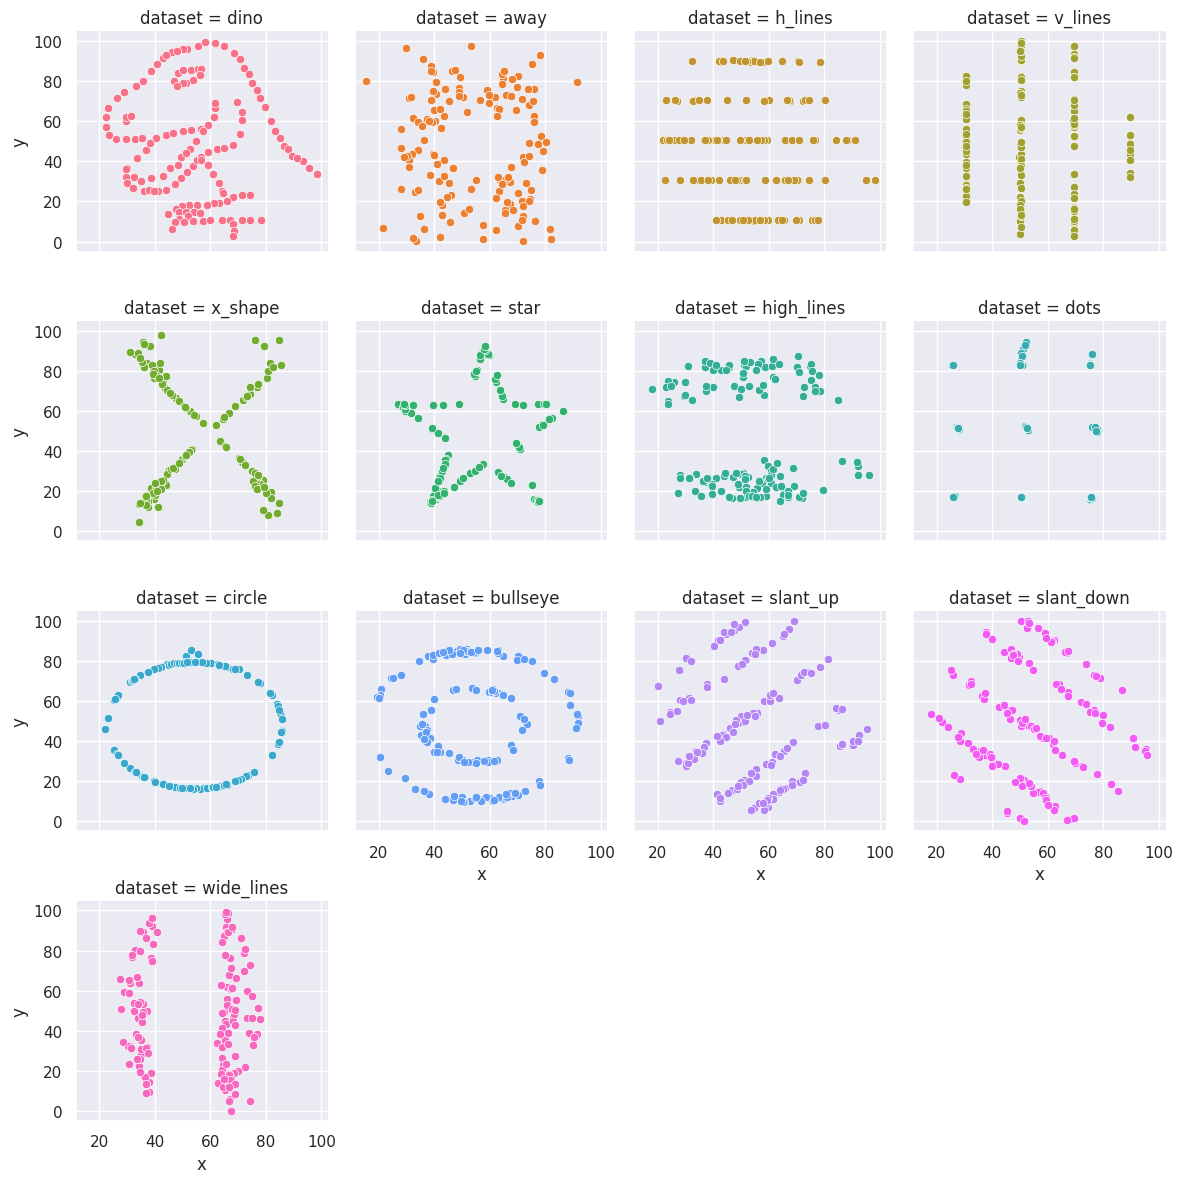

In [6]:
import pandas as pd

data = pd.read_csv('DatasaurusDozen.tsv', sep='\t')
data.head()

len(data['dataset'].unique())
data['dataset'].unique()

datasets_grouped = data.groupby('dataset')
datasets_grouped.agg(['count', 'mean', 'var', 'std'])

import seaborn as sns

grid_scatterplots = sns.FacetGrid(data, col="dataset", hue="dataset", col_wrap=4)
grid_scatterplots.map_dataframe(sns.scatterplot, x="x", y="y")

# Große Übungsaufgabe: Kombination des Gelernten anhand des Titanic-Datensatzes / *Big exercise: putting it all together with the titanic dataset*

Lass uns einen Datensatz eigenständig erkunden und das Gelernte anwenden, um Visualisierung für eine Analyse zu nutzen!

Den Titanic-Datensatz und eine zugehörige Tutorial-Aufgabe gibt es auf Kaggle: https://www.kaggle.com/c/titanic

Um es einfacher zu machen, verwenden wir den verfügbaren Datensatz über Seaborns load_dataset-Funktion, wir können ihn aber auch direkt aus Kaggle laden. Lasst uns zunächst eine Zusammenfassung des Datensatzes ausgeben.

---

*Let's explore a dataset on our own and apply what we have learned in terms of using visualization for some analysis!*

*You can find the Titanic dataset and a corresponding tutorial challenge on Kaggle at https://www.kaggle.com/c/titanic*

*To make it easier for us, we will use the available dataset through seaborns load_dataset function, but you can also load it from Kaggle. Let's print a summary of the dataset.*

In [7]:
titanic = sns.load_dataset("titanic")
print(titanic.info())
print(titanic.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
         survived      pclass         age       sibsp       parch        f

<Axes: xlabel='age', ylabel='sex'>

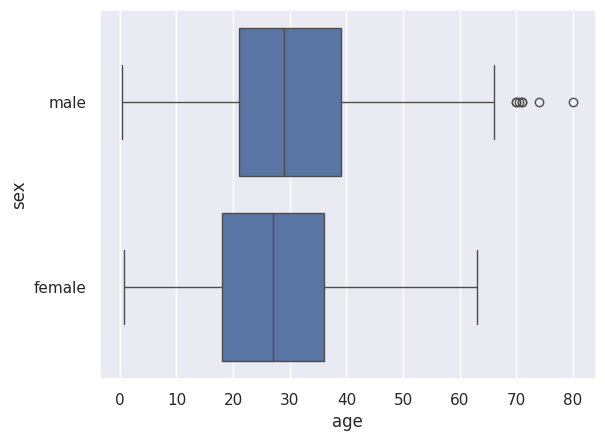

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

titanic = sns.load_dataset("titanic")
titanic.head()

# count per category
titanic.count()

# excluding datasns.countplot(titanic, x="class", hue="survived", stat="percent")
titanic = titanic.dropna(subset=['embarked', 'embark_town'])

# change to numbers
emb = {
    "C": 0,
    "Q": 1,
    "S": 2
}

emb_town = {
    "Cherbourg": 0,
    "Queenstown": 1,
    "Southampton": 2
}

titanic.embarked = [emb[item] for item in titanic.embarked] # bei replace immer genauer drauf schauen!
#titanic.embark_town = [emb_town[item] for item in titanic.embark_town]

# choose only one representation
titanic.drop(["class", "who", "adult_male", "alive"], axis=1)

# boxplot age vs gender
fig = plt.figure()
sns.boxplot(data=titanic, x=titanic.age, y=titanic.sex)



<Axes: xlabel='sex', ylabel='count'>

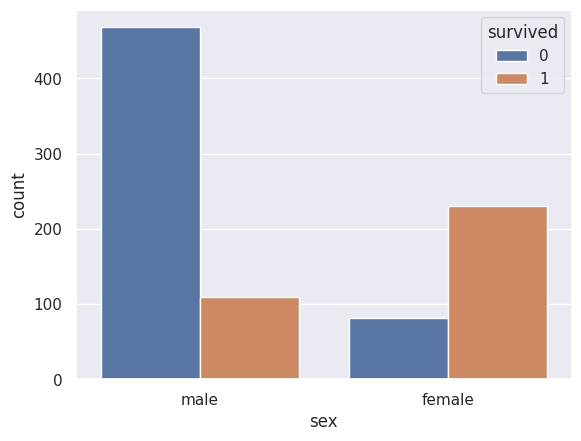

In [84]:
# Display the survival rates as a function of gender and class of a passenger
sns.countplot(titanic, x=titanic.sex, hue=titanic.survived)

<Axes: xlabel='pclass', ylabel='count'>

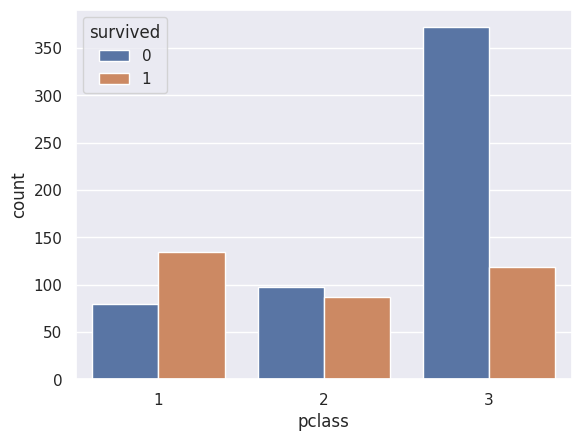

In [83]:
# Display the survival rates as a function of gender and class of a passenger
sns.countplot(titanic, x=titanic.pclass, hue=titanic.survived)

### Aufgaben / *Tasks to do*:

Schauen wir uns den Datensatz genauer an und wählen geeignete Features für unsere Analyse aus.

* Beginne damit, die Anzahl pro Kategorie zu ermitteln. Dazu kannst du die Funktion `count()` verwenden.
* Wir werden feststellen, dass einige Einträge unvollständig sind und Daten für bestimmte Passagiere fehlen. Dies ist bei realen Datensätzen üblich, und wir müssen Wege finden, damit umzugehen. Sieh speziell die Kategorien `embarked` und `embark_town` an. Es wird nur zwei Passagiere geben, bei denen dieser Wert fehlt. Schließe sie für die weitere Analyse aus.
* Bei näherer Betrachtung werden wir sehen, dass einige Features numerische Werte enthalten, während andere Strings haben. Das ist zum Beispiel bei `embarked` der Fall, wobei C, Q und S für Städte stehen (Cherbourg, Queenstown, Southampton). Es ist oft nützlich, diese für Visualisierung oder spätere Data-Science-Methoden in Zahlen zu überführen. Ersetze also C, Q und S durch die ganzen Zahlen 0, 1 und 2.
* Einige Features existieren mehrfach in unterschiedlichen Darstellungen, z. B. `pclass` und `class`. Eines ist numerisch, eines als String. Wähle nur eines davon aus.
* Sobald die obigen Schritte vorbereitet sind, starte die visuelle Analyse mit einem Boxplot von Geschlecht versus Alter.
* Zeige die Überlebensraten als Funktion von Geschlecht und Klasse eines Passagiers an. Alternativ zu den bisherigen Matplotlib-Plots kann auch die Seaborn-Funktion verwenden werden, falls eine Herausforderung gewünscht ist: `seaborn.countplot`.
* Auf Basis dieser Visualisierungen könnten wir bereits einen ersten handgefertigten einfachen Klassifikator bauen. Aus den Figuren lässt sich erkennen, dass Überleben stark mit weiblichen Passagieren der ersten Klasse zusammenhängt. Wenn die obige Aufgabe noch nicht herausfordernd genug war und noch Zeit ist, oder du dies als Übung zuhause machen möchtest, versuche eine einfache Regel zu entwickeln, die das Überleben anhand von Geschlecht und Passagierklasse vorhersagt.

---

*Let us take a closer look at the dataset and select suitable features for our analysis.*

*   *Start by getting a count per category. You can make use of the `count()` function to this end*
*   *You will notice some incomplete data entries and missing data for certain passangers. This is usually the case for real world data and we will need to find ways to handle this. Specifically, take a look at the `embarked` and `embark_town` categories. You will find that there are only two passangers for whom this value is missing. Try excluding them from the dataset for future analysis.*
* *Upon further inspection, you will see that some features have numerical values, whereas others contain strings. This is the case for the `embarked` category, where C, Q and S correspond to towns (Cherbourg, Queenstown, Southampton). It is often useful, for visualization or later data science methods to map these to numbers instead. Try replacing the C, Q and S, with integer values of 0, 1 and 2 instead.*
* *You will see that some features also exist multiple times in the data frame in multiple representations, such as `pclass` and `class`. Here, one is numerical and one is in string format. Select only one of them.*
* *Once above steps are prepared, start your visual analysis by plotting a boxplot of biological sex versus age.*
* *Display the survival rates as a function of gender and class of a passenger. As an alternative to our above matplotlib plots, you can also use the seaborn function if you want to be challenged: `seaborn.countplot`*
* *We could already build our first hand-engineered simple classifier based on our insights from these visualizations. From the figures we can observe that survival is very much related to being a female first class passenger. If you thought the above wasn't challenging enough and you still have time, or want to do an exercise at home, try coming up with a simple rule that predicts survival based on gener and passenger class.*






In [ ]:
# add your solutions here